Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training images: 5600
Testing images: 1600


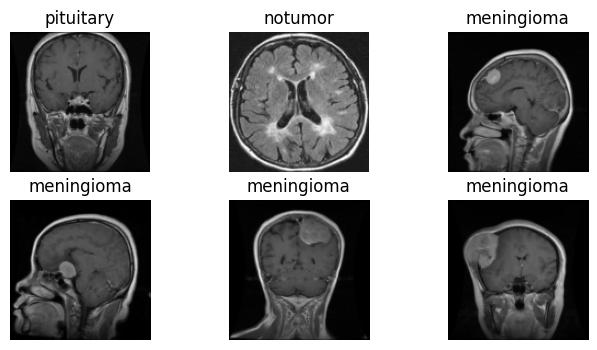

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import os
Results_folder = r"C:\Users\user\Desktop\Brain-Tumor-Detection-CNN\Results"
#devicee
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",device)
#dataset paths
train_dir=r"C:\Users\user\Desktop\Brain-Tumor-Detection-CNN\Data\Training"
test_dir=r"C:\Users\user\Desktop\Brain-Tumor-Detection-CNN\Data\Testing"
#transforms
transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
#load datasets
train_data=ImageFolder(train_dir,transform=transform)
test_data =ImageFolder(test_dir,transform=transform)
#dataloaders
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
test_loader=DataLoader(test_data,batch_size=32,shuffle=False)
classes=train_data.classes
print("Classes:", classes)
print("Training images:",len(train_data))
print("Testing images:",len(test_data))
images, labels=next(iter(train_loader))
#unnormalize for a better visualisation/display of tumour images
images=images*0.5 +0.5
plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(classes[labels[i]])
    plt.axis("off")
plt.show()

Using device: cuda
Epoch1/10,loss:0.6879,accuracy:84.89%
Epoch2/10,loss:0.3635,accuracy:91.38%
Epoch3/10,loss:0.2232,accuracy:95.14%
Epoch4/10,loss:0.1343,accuracy:97.41%
Epoch5/10,loss:0.0876,accuracy:97.41%
Epoch6/10,loss:0.0673,accuracy:98.96%
Epoch7/10,loss:0.0368,accuracy:98.77%
Epoch8/10,loss:0.0185,accuracy:99.79%
Epoch9/10,loss:0.0068,accuracy:99.82%
Epoch10/10,loss:0.0141,accuracy:97.95%


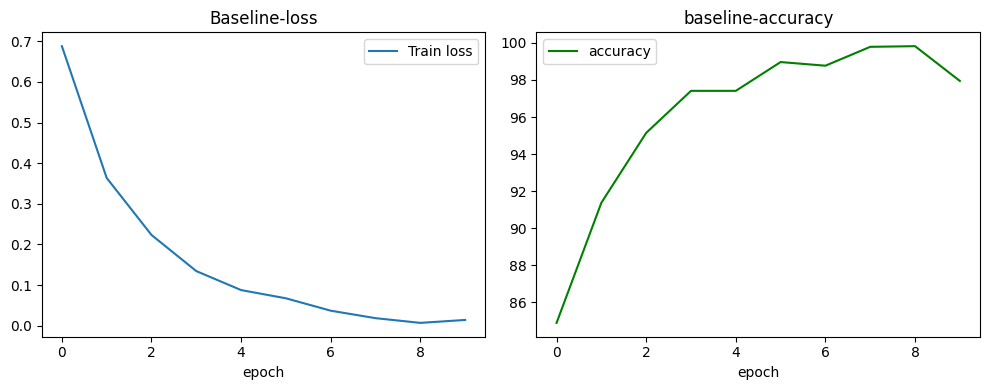

In [23]:
#picking gpu
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",device)
#basic model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN,self).__init__()
        self.conv1=nn.Conv2d(3,32,kernel_size=3,padding=1)
        self.conv2=nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.conv3=nn.Conv2d(64,128,kernel_size=3,padding=1)
        self.pool=nn.MaxPool2d(2,2)
        self.fc1=nn.Linear(128*16*16,256)
        self.fc2=nn.Linear(256,4)

    def forward(self,x):
        x=self.pool(torch.relu(self.conv1(x)))
        x=self.pool(torch.relu(self.conv2(x)))
        x=self.pool(torch.relu(self.conv3(x)))
        x=x.view(x.size(0),-1)
        x=torch.relu(self.fc1(x))
        x=self.fc2(x)
        return x

#trainning
def trainmodel(model,train_loader,epochs=10,lr=0.001):
    model=model.to(device)
    criterion=nn.CrossEntropyLoss()
    optimizer=optim.Adam(model.parameters(),lr=lr)
    train_losses=[]
    accuracies=[]
    for epoch in range(epochs):
        model.train()
        running_loss=0
        for images,labels in train_loader:
            images=images.to(device)
            labels=labels.to(device)
            optimizer.zero_grad()
            outputs=model(images)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss+=loss.item()
        train_loss=running_loss/len(train_loader)
        train_losses.append(train_loss)

        #validation
        model.eval()
        correct=0
        total=0
        with torch.no_grad():
            for images,labels in train_loader:
                images=images.to(device)
                labels=labels.to(device)
                outputs=model(images)
                _, preds=torch.max(outputs,1)
                correct+=(preds==labels).sum().item()
                total+=labels.size(0)
        acc=100*correct/total
        accuracies.append(acc)
        print(f"Epoch{epoch+1}/{epochs},loss:{train_loss:.4f},accuracy:{acc:.2f}%")
    return train_losses,accuracies

base_model=SimpleCNN()
b_losses,b_accs=trainmodel(base_model,train_loader,epochs=10)
#plotting results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(b_losses, label='Train loss')
plt.title('Baseline-loss')
plt.xlabel('epoch')
plt.legend()
plt.subplot(1,2,2)
plt.plot(b_accs,color='green',label='accuracy')
plt.title('baseline-accuracy')
plt.xlabel('epoch')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(Results_folder,"baseline_training.png"))
plt.show()

Epoch1/10,loss:1.3769,accuracy:81.93%
Epoch2/10,loss:0.6049,accuracy:86.21%
Epoch3/10,loss:0.5666,accuracy:82.36%
Epoch4/10,loss:0.5039,accuracy:87.34%
Epoch5/10,loss:0.4783,accuracy:83.73%
Epoch6/10,loss:0.4187,accuracy:88.59%
Epoch7/10,loss:0.4008,accuracy:91.07%
Epoch8/10,loss:0.3782,accuracy:90.07%
Epoch9/10,loss:0.3587,accuracy:92.18%
Epoch10/10,loss:0.3477,accuracy:93.61%


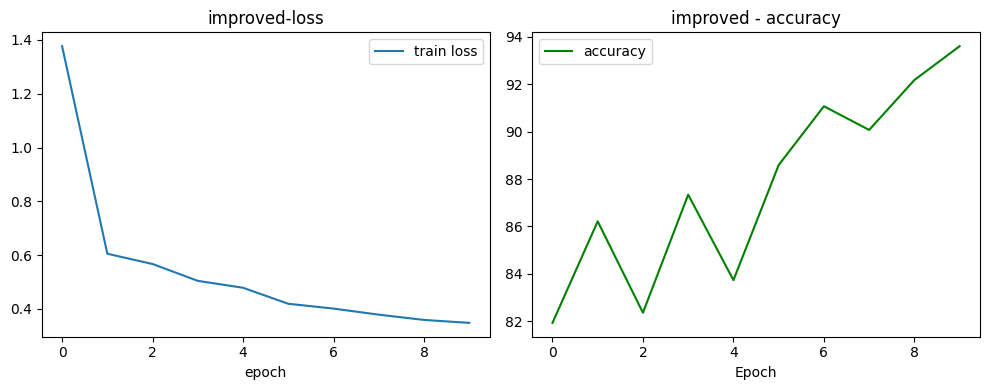

In [24]:
#optimized model with dropout and batch norm
class improvedCNN(nn.Module):
    def __init__(self):
        super(improvedCNN, self).__init__()
        self.conv1=nn.Conv2d(3, 32,kernel_size=3,padding=1)
        self.bn1=nn.BatchNorm2d(32)
        self.conv2=nn.Conv2d(32, 64,kernel_size=3,padding=1)
        self.bn2=nn.BatchNorm2d(64)
        self.conv3=nn.Conv2d(64, 128,kernel_size=3,padding=1)
        self.bn3=nn.BatchNorm2d(128)
        self.pool=nn.MaxPool2d(2,2)
        self.fc1=nn.Linear(128*16*16,256)
        self.dropout=nn.Dropout(0.5)
        self.fc2=nn.Linear(256,4)

    def forward(self,x):
        x=self.pool(torch.relu(self.bn1(self.conv1(x))))
        x=self.pool(torch.relu(self.bn2(self.conv2(x))))
        x=self.pool(torch.relu(self.bn3(self.conv3(x))))
        x=x.view(x.size(0),-1)
        x=self.dropout(torch.relu(self.fc1(x)))
        x=self.fc2(x)
        return x

#model to GPU
improved_model=improvedCNN().to(device)
i_losses,i_accs=trainmodel(improved_model,train_loader,epochs=10)
# plotting results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(i_losses,label='train loss')
plt.title('improved-loss'); plt.xlabel('epoch'); 
plt.legend()
plt.subplot(1,2,2)
plt.plot(i_accs,color='green',label='accuracy')
plt.title('improved - accuracy'); plt.xlabel('Epoch')
plt.savefig(os.path.join(Results_folder, "sample_predictions.png"))
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(Results_folder,"improved_training.png"))
plt.show()


Base model test accuracy:87.19%
Improved model test acuracy:82.19%

Base model CNN
              precision    recall  f1-score   support

      glioma       0.87      0.78      0.82       400
  meningioma       0.92      0.76      0.83       400
     notumor       0.79      1.00      0.88       400
   pituitary       0.94      0.95      0.94       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600


Improved model CNN
              precision    recall  f1-score   support

      glioma       0.79      0.71      0.75       400
  meningioma       0.74      0.73      0.74       400
     notumor       0.80      0.97      0.88       400
   pituitary       0.96      0.88      0.92       400

    accuracy                           0.82      1600
   macro avg       0.83      0.82      0.82      1600
weighted avg       0.83      0.82      0.82      1600



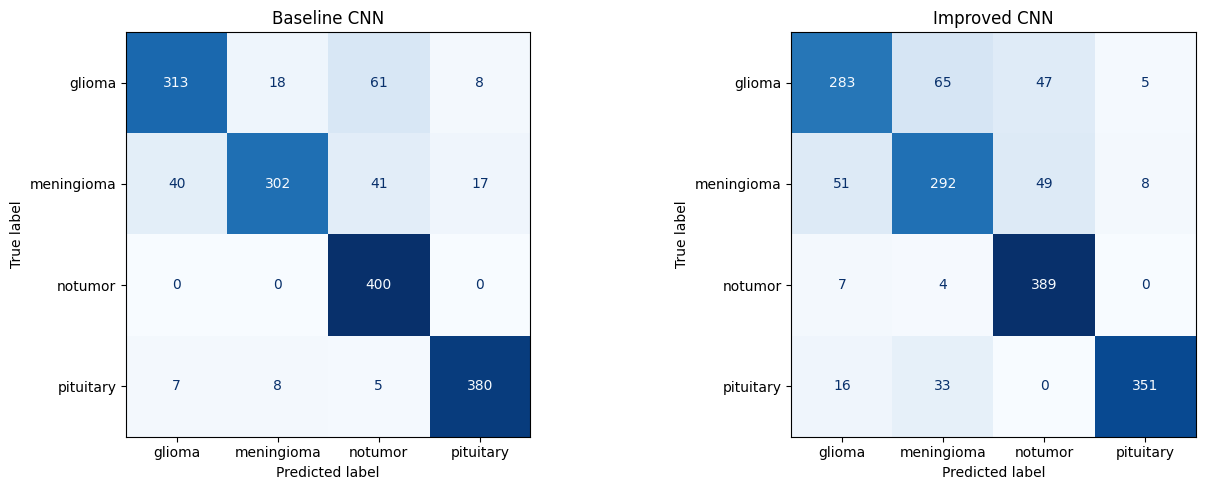

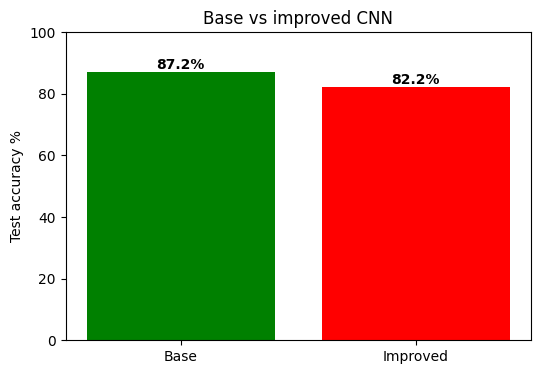

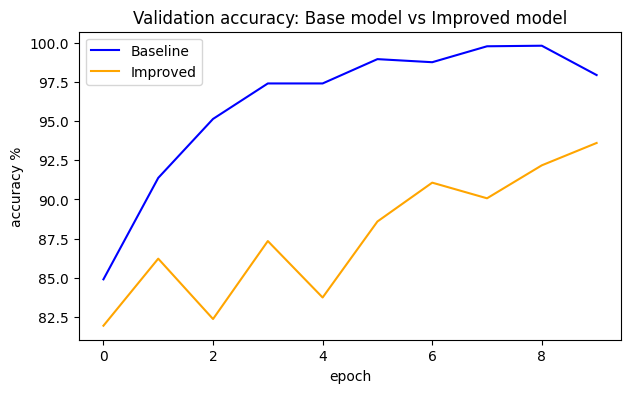

In [25]:
#comparision between simple and iimproved model
def evaluate_model(model,loader):
    model.eval()
    all_preds=[]
    all_labels=[]
    correct=0
    total=0
    with torch.no_grad():
        for images,labels in loader:
            images,labels=images.to(device),labels.to(device)
            outputs=model(images)
            _, preds=torch.max(outputs,1)
            correct+=(preds==labels).sum().item()
            total+=labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc=100*correct/total
    return acc,all_preds,all_labels
b_acc,b_preds,b_labels=evaluate_model(base_model,test_loader)
i_acc,i_preds,i_labels=evaluate_model(improved_model,test_loader)

print(f"Base model test accuracy:{b_acc:.2f}%")
print(f"Improved model test acuracy:{i_acc:.2f}%")

print("\nBase model CNN")
print(classification_report(b_labels,b_preds,target_names=classes))
print("\nImproved model CNN")
print(classification_report(i_labels,i_preds,target_names=classes))
#confusion matrices
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,preds,labels,title in zip(
    axes,
    [b_preds,i_preds],
    [b_labels,i_labels],
    ['Baseline CNN','Improved CNN']
):
    cm=confusion_matrix(labels,preds)
    disp=ConfusionMatrixDisplay(cm,display_labels=classes)
    disp.plot(ax=ax, colorbar=False,cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.savefig(os.path.join(Results_folder,"confusion_matrices.png"))
plt.show()

#bar chart accuracy comparision
plt.figure(figsize=(6,4))
plt.bar(['Base','Improved'],[b_acc,i_acc],color=['green','red'])
plt.ylabel('Test accuracy %')
plt.title('Base vs improved CNN')
plt.ylim(0,100)
for i,v in enumerate([b_acc,i_acc]):
    plt.text(i,v+1,f'{v:.1f}%',ha='center',fontweight='bold')
plt.savefig(os.path.join(Results_folder,"accuracy_comparison.png"))
plt.show()

#accuracy comparison in epochs
plt.figure(figsize=(7,4))
plt.plot(b_accs, label='Baseline',color='blue')
plt.plot(i_accs, label='Improved', color='orange')
plt.title('Validation accuracy: Base model vs Improved model')
plt.xlabel('epoch'); plt.ylabel('accuracy %')
plt.legend()
plt.savefig(os.path.join(Results_folder,"validation_accuracy_comparison.png"))
plt.show()